# Análise de Correspondência Múltipla (MCA)

**Tema:** perfil de consumo em plataformas de streaming.

Neste notebook, será aplicada a **Análise de Correspondência Múltipla (MCA)** para investigar associações entre variáveis categóricas de clientes fictícios, como faixa etária, dispositivo utilizado, conteúdo preferido, tipo de plano e período de uso.

A MCA é uma extensão da ANACOR para mais de duas variáveis categóricas. Enquanto a ANACOR normalmente utiliza uma matriz de contingência como entrada, a MCA utiliza o banco de dados original com as variáveis categóricas.

In [17]:
#%% Instalação dos pacotes, caso necessário

# Descomente as linhas abaixo se algum pacote não estiver instalado no seu ambiente.
# !pip install pandas
# !pip install numpy
# !pip install scipy
# !pip install matplotlib
# !pip install prince

#%% Importando os pacotes necessários

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import prince

In [2]:
#%% Importando o banco de dados

# Dataset fictício criado para fins didáticos e publicação no GitHub.
# Cada linha representa um cliente e suas características categóricas de consumo em streaming.

streaming_mca = pd.read_csv("clientes_streaming_mca.csv")

streaming_mca.head()

,cliente_id,faixa_etaria,dispositivo_principal,conteudo_preferido,tipo_plano,periodo_uso
0,129,60+ anos,Smart TV,Documentários,Premium,Tarde
1,46,18-25 anos,Notebook/PC,Animes,Básico,Madrugada
2,135,60+ anos,Smart TV,Documentários,Premium,Tarde
3,157,26-40 anos,Smartphone,Animes,Básico,Fim de semana
4,91,26-40 anos,Notebook/PC,Documentários,Padrão,Fim de semana


In [3]:
#%% Selecionando apenas as variáveis categóricas que serão usadas na MCA

# A coluna cliente_id é apenas um identificador e não deve entrar na análise.

dados_mca = streaming_mca.drop(columns=["cliente_id"])

dados_mca.head()

,faixa_etaria,dispositivo_principal,conteudo_preferido,tipo_plano,periodo_uso
0,60+ anos,Smart TV,Documentários,Premium,Tarde
1,18-25 anos,Notebook/PC,Animes,Básico,Madrugada
2,60+ anos,Smart TV,Documentários,Premium,Tarde
3,26-40 anos,Smartphone,Animes,Básico,Fim de semana
4,26-40 anos,Notebook/PC,Documentários,Padrão,Fim de semana


In [4]:
#%% Informações descritivas das variáveis categóricas

# Esta etapa ajuda a entender a distribuição das categorias antes da análise.

for coluna in dados_mca.columns:
    print(f"\nVariável: {coluna}")
    print(dados_mca[coluna].value_counts())


Variável: faixa_etaria
faixa_etaria
18-25 anos    54
26-40 anos    48
41-60 anos    34
60+ anos      22
Name: count, dtype: int64

Variável: dispositivo_principal
dispositivo_principal
Smart TV       71
Smartphone     46
Notebook/PC    21
Tablet         20
Name: count, dtype: int64

Variável: conteudo_preferido
conteudo_preferido
Séries              59
Documentários       39
Filmes              35
Animes              16
Filmes clássicos     9
Name: count, dtype: int64

Variável: tipo_plano
tipo_plano
Padrão     58
Básico     51
Premium    49
Name: count, dtype: int64

Variável: periodo_uso
periodo_uso
Noite            94
Fim de semana    28
Tarde            23
Madrugada        12
Manhã             1
Name: count, dtype: int64


In [5]:
#%% Analisando algumas tabelas de contingência

# Antes da MCA, é útil observar cruzamentos entre pares de variáveis.
# Essas tabelas ajudam a identificar possíveis associações preliminares.

tabela_1 = pd.crosstab(dados_mca["faixa_etaria"], dados_mca["dispositivo_principal"])
tabela_2 = pd.crosstab(dados_mca["faixa_etaria"], dados_mca["conteudo_preferido"])
tabela_3 = pd.crosstab(dados_mca["dispositivo_principal"], dados_mca["tipo_plano"])

print("Faixa etária x Dispositivo principal")
print(tabela_1)

print("\nFaixa etária x Conteúdo preferido")
print(tabela_2)

print("\nDispositivo principal x Tipo de plano")
print(tabela_3)

Faixa etária x Dispositivo principal
dispositivo_principal  Notebook/PC  Smart TV  Smartphone  Tablet
faixa_etaria                                                    
18-25 anos                      12         2          39       1
26-40 anos                       8        37           2       1
41-60 anos                       0        20           4      10
60+ anos                         1        12           1       8

Faixa etária x Conteúdo preferido
conteudo_preferido  Animes  Documentários  Filmes  Filmes clássicos  Séries
faixa_etaria                                                               
18-25 anos              14              0       1                 0      39
26-40 anos               2              9      22                 0      15
41-60 anos               0             18      12                 0       4
60+ anos                 0             12       0                 9       1

Dispositivo principal x Tipo de plano
tipo_plano             Básico  Padrão  Prem

In [6]:
#%% Teste qui-quadrado para verificar associação entre pares de variáveis

# O teste qui-quadrado avalia se duas variáveis categóricas são independentes.
# H0: as variáveis são independentes.
# H1: existe associação entre as variáveis.

def teste_quiquadrado(tabela, nome):
    chi2, p_valor, gl, esperados = chi2_contingency(tabela)
    print(f"\nAssociação: {nome}")
    print(f"Qui-quadrado: {chi2:.2f}")
    print(f"p-valor: {p_valor:.4f}")
    print(f"Graus de liberdade: {gl}")
    
    if p_valor < 0.05:
        print("Conclusão: rejeita-se H0. Há evidências de associação.")
    else:
        print("Conclusão: não se rejeita H0. Não há evidências fortes de associação.")

teste_quiquadrado(tabela_1, "Faixa etária x Dispositivo principal")
teste_quiquadrado(tabela_2, "Faixa etária x Conteúdo preferido")
teste_quiquadrado(tabela_3, "Dispositivo principal x Tipo de plano")


Associação: Faixa etária x Dispositivo principal
Qui-quadrado: 122.15
p-valor: 0.0000
Graus de liberdade: 9
Conclusão: rejeita-se H0. Há evidências de associação.

Associação: Faixa etária x Conteúdo preferido
Qui-quadrado: 169.35
p-valor: 0.0000
Graus de liberdade: 12
Conclusão: rejeita-se H0. Há evidências de associação.

Associação: Dispositivo principal x Tipo de plano
Qui-quadrado: 93.31
p-valor: 0.0000
Graus de liberdade: 6
Conclusão: rejeita-se H0. Há evidências de associação.


In [7]:
#%% Elaborando a MCA

# Na MCA, o input é o próprio banco de dados com variáveis categóricas.
# Isso é diferente da ANACOR, em que normalmente usamos uma matriz de contingência.

mca = prince.MCA(
    n_components=2,
    random_state=42
).fit(dados_mca)

In [8]:
#%% Quantidade total de dimensões possíveis na MCA

# Na MCA, a quantidade máxima de dimensões é dada por:
# quantidade total de categorias - quantidade de variáveis.

quantidade_categorias = mca.J_
quantidade_variaveis = mca.K_
quantidade_dimensoes = quantidade_categorias - quantidade_variaveis

print(f"Quantidade total de categorias: {quantidade_categorias}")
print(f"Quantidade de variáveis: {quantidade_variaveis}")
print(f"Quantidade máxima de dimensões: {quantidade_dimensoes}")

Quantidade total de categorias: 21
Quantidade de variáveis: 5
Quantidade máxima de dimensões: 16


In [9]:
#%% Visualizando a matriz binária e a matriz de Burt

# A MCA trabalha com uma representação binária das categorias.
# Cada categoria vira uma coluna indicadora, assumindo valor 1 quando o indivíduo pertence àquela categoria.
# A matriz de Burt é obtida pelo produto da matriz binária transposta pela matriz binária.

binaria = pd.get_dummies(dados_mca, columns=dados_mca.columns, dtype=float)
burt = np.matmul(binaria.T, binaria)

print("Matriz binária:")
print(binaria.head())

print("\nMatriz de Burt:")
print(pd.DataFrame(burt, index=binaria.columns, columns=binaria.columns).head())

Matriz binária:
   faixa_etaria_18-25 anos  faixa_etaria_26-40 anos  faixa_etaria_41-60 anos  \
0                      0.0                      0.0                      0.0   
1                      1.0                      0.0                      0.0   
2                      0.0                      0.0                      0.0   
3                      0.0                      1.0                      0.0   
4                      0.0                      1.0                      0.0   

   faixa_etaria_60+ anos  dispositivo_principal_Notebook/PC  \
0                    1.0                                0.0   
1                    0.0                                1.0   
2                    1.0                                0.0   
3                    0.0                                0.0   
4                    0.0                                1.0   

   dispositivo_principal_Smart TV  dispositivo_principal_Smartphone  \
0                             1.0                    

In [10]:
#%% Obtendo os autovalores e a inércia explicada

# Os autovalores indicam quanta informação cada dimensão explica.
# Na MCA e na ANACOR, essa informação é chamada de inércia.

tabela_autovalores = mca.eigenvalues_summary

print(tabela_autovalores)

### Veja que se escolhermos apenas 2 dimensões ou 2 eixos, 
# deixamos informações de fore, veja que com 2 dimensões conseguimos explicar apenas 39.93% das informações da variancia.

# Observa-se que, ao manter apenas as duas primeiras dimensões,
# o mapa perceptual representa 39,93% da inércia (variancia) total.
# A Dimensão 1 explica 21,97% e a Dimensão 2 explica 17,96%.
# Portanto, o gráfico bidimensional resume parte relevante da estrutura
# de associação entre as categorias, mas não representa 100% da informação.

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.703        21.97%                     21.97%
1              0.575        17.96%                     39.93%


In [11]:
#%% Inércia principal total

# A inércia total representa a informação associativa total presente na análise.

print(f"Inércia total: {mca.total_inertia_:.4f}")

Inércia total: 3.2000


In [12]:
#%% Coordenadas principais das categorias

# As coordenadas permitem transformar categorias em pontos numéricos no plano.
# Cada categoria recebe uma coordenada na Dimensão 1 e outra na Dimensão 2.

coord_categorias = mca.column_coordinates(dados_mca)

print(coord_categorias)

                                             0         1
faixa_etaria__18-25 anos              1.227844  0.006599
faixa_etaria__26-40 anos             -0.375297 -0.691310
faixa_etaria__41-60 anos             -0.890233 -0.206674
faixa_etaria__60+ anos               -0.819154  1.811522
dispositivo_principal__Notebook/PC    0.894744  0.900887
dispositivo_principal__Smart TV      -0.773771 -0.241037
dispositivo_principal__Smartphone     0.952365 -0.427705
dispositivo_principal__Tablet        -0.383034  0.893470
conteudo_preferido__Animes            1.645903  1.129986
conteudo_preferido__Documentários    -1.138424  0.506116
conteudo_preferido__Filmes           -0.428224 -0.908042
conteudo_preferido__Filmes clássicos -0.365318  2.533373
conteudo_preferido__Séries            0.615929 -0.488766
tipo_plano__Básico                    1.079885  0.613294
tipo_plano__Padrão                   -0.171912 -0.706974
tipo_plano__Premium                  -0.920474  0.198500
periodo_uso__Fim de semana     

In [13]:
#%% Coordenadas-padrão das categorias

# As coordenadas-padrão ajudam a visualizar melhor a posição relativa das categorias no mapa perceptual.

coord_padrao = mca.column_coordinates(dados_mca) / np.sqrt(mca.eigenvalues_)

print(coord_padrao)

                                             0         1
faixa_etaria__18-25 anos              1.464372  0.008705
faixa_etaria__26-40 anos             -0.447593 -0.911955
faixa_etaria__41-60 anos             -1.061725 -0.272638
faixa_etaria__60+ anos               -0.976954  2.389705
dispositivo_principal__Notebook/PC    1.067105  1.188423
dispositivo_principal__Smart TV      -0.922828 -0.317968
dispositivo_principal__Smartphone     1.135826 -0.564215
dispositivo_principal__Tablet        -0.456821  1.178639
conteudo_preferido__Animes            1.962965  1.490644
conteudo_preferido__Documentários    -1.357727  0.667653
conteudo_preferido__Filmes           -0.510716 -1.197862
conteudo_preferido__Filmes clássicos -0.435691  3.341949
conteudo_preferido__Séries            0.734580 -0.644765
tipo_plano__Básico                    1.287911  0.809039
tipo_plano__Padrão                   -0.205028 -0.932619
tipo_plano__Premium                  -1.097792  0.261855
periodo_uso__Fim de semana     

In [14]:
#%% Coordenadas das observações

# Cada cliente também pode ser representado como um ponto no espaço da MCA.
# Neste projeto, o foco será no mapa das categorias.

coord_observacoes = mca.row_coordinates(dados_mca)

print(coord_observacoes.head())

          0         1
0 -1.070973  1.057668
1  1.616258  1.072710
2 -1.070973  1.057668
3  0.549794  0.186803
4 -0.426677  0.024402


In [15]:
#%% Preparando os dados para o mapa perceptual

chart = coord_padrao.reset_index()

# O prince cria nomes como variavel__categoria ou variavel_categoria, dependendo da versão.
# A função abaixo tenta separar o nome da variável de forma robusta.

def extrair_variavel(nome_categoria):
    nome_categoria = str(nome_categoria)
    for coluna in dados_mca.columns:
        if nome_categoria.startswith(coluna):
            return coluna
    return "categoria"

chart_df_mca = pd.DataFrame({
    "categoria": chart["index"],
    "x": chart[0],
    "y": chart[1],
})

chart_df_mca["variavel"] = chart_df_mca["categoria"].apply(extrair_variavel)

chart_df_mca

,categoria,x,y,variavel
0,faixa_etaria__18-25 anos,1.464372,0.008705,faixa_etaria
1,faixa_etaria__26-40 anos,-0.447593,-0.911955,faixa_etaria
2,faixa_etaria__41-60 anos,-1.061725,-0.272638,faixa_etaria
3,faixa_etaria__60+ anos,-0.976954,2.389705,faixa_etaria
4,dispositivo_principal__Notebook/PC,1.067105,1.188423,dispositivo_principal
5,dispositivo_principal__Smart TV,-0.922828,-0.317968,dispositivo_principal
6,dispositivo_principal__Smartphone,1.135826,-0.564215,dispositivo_principal
7,dispositivo_principal__Tablet,-0.456821,1.178639,dispositivo_principal
8,conteudo_preferido__Animes,1.962965,1.490644,conteudo_preferido
9,conteudo_preferido__Documentários,-1.357727,0.667653,conteudo_preferido


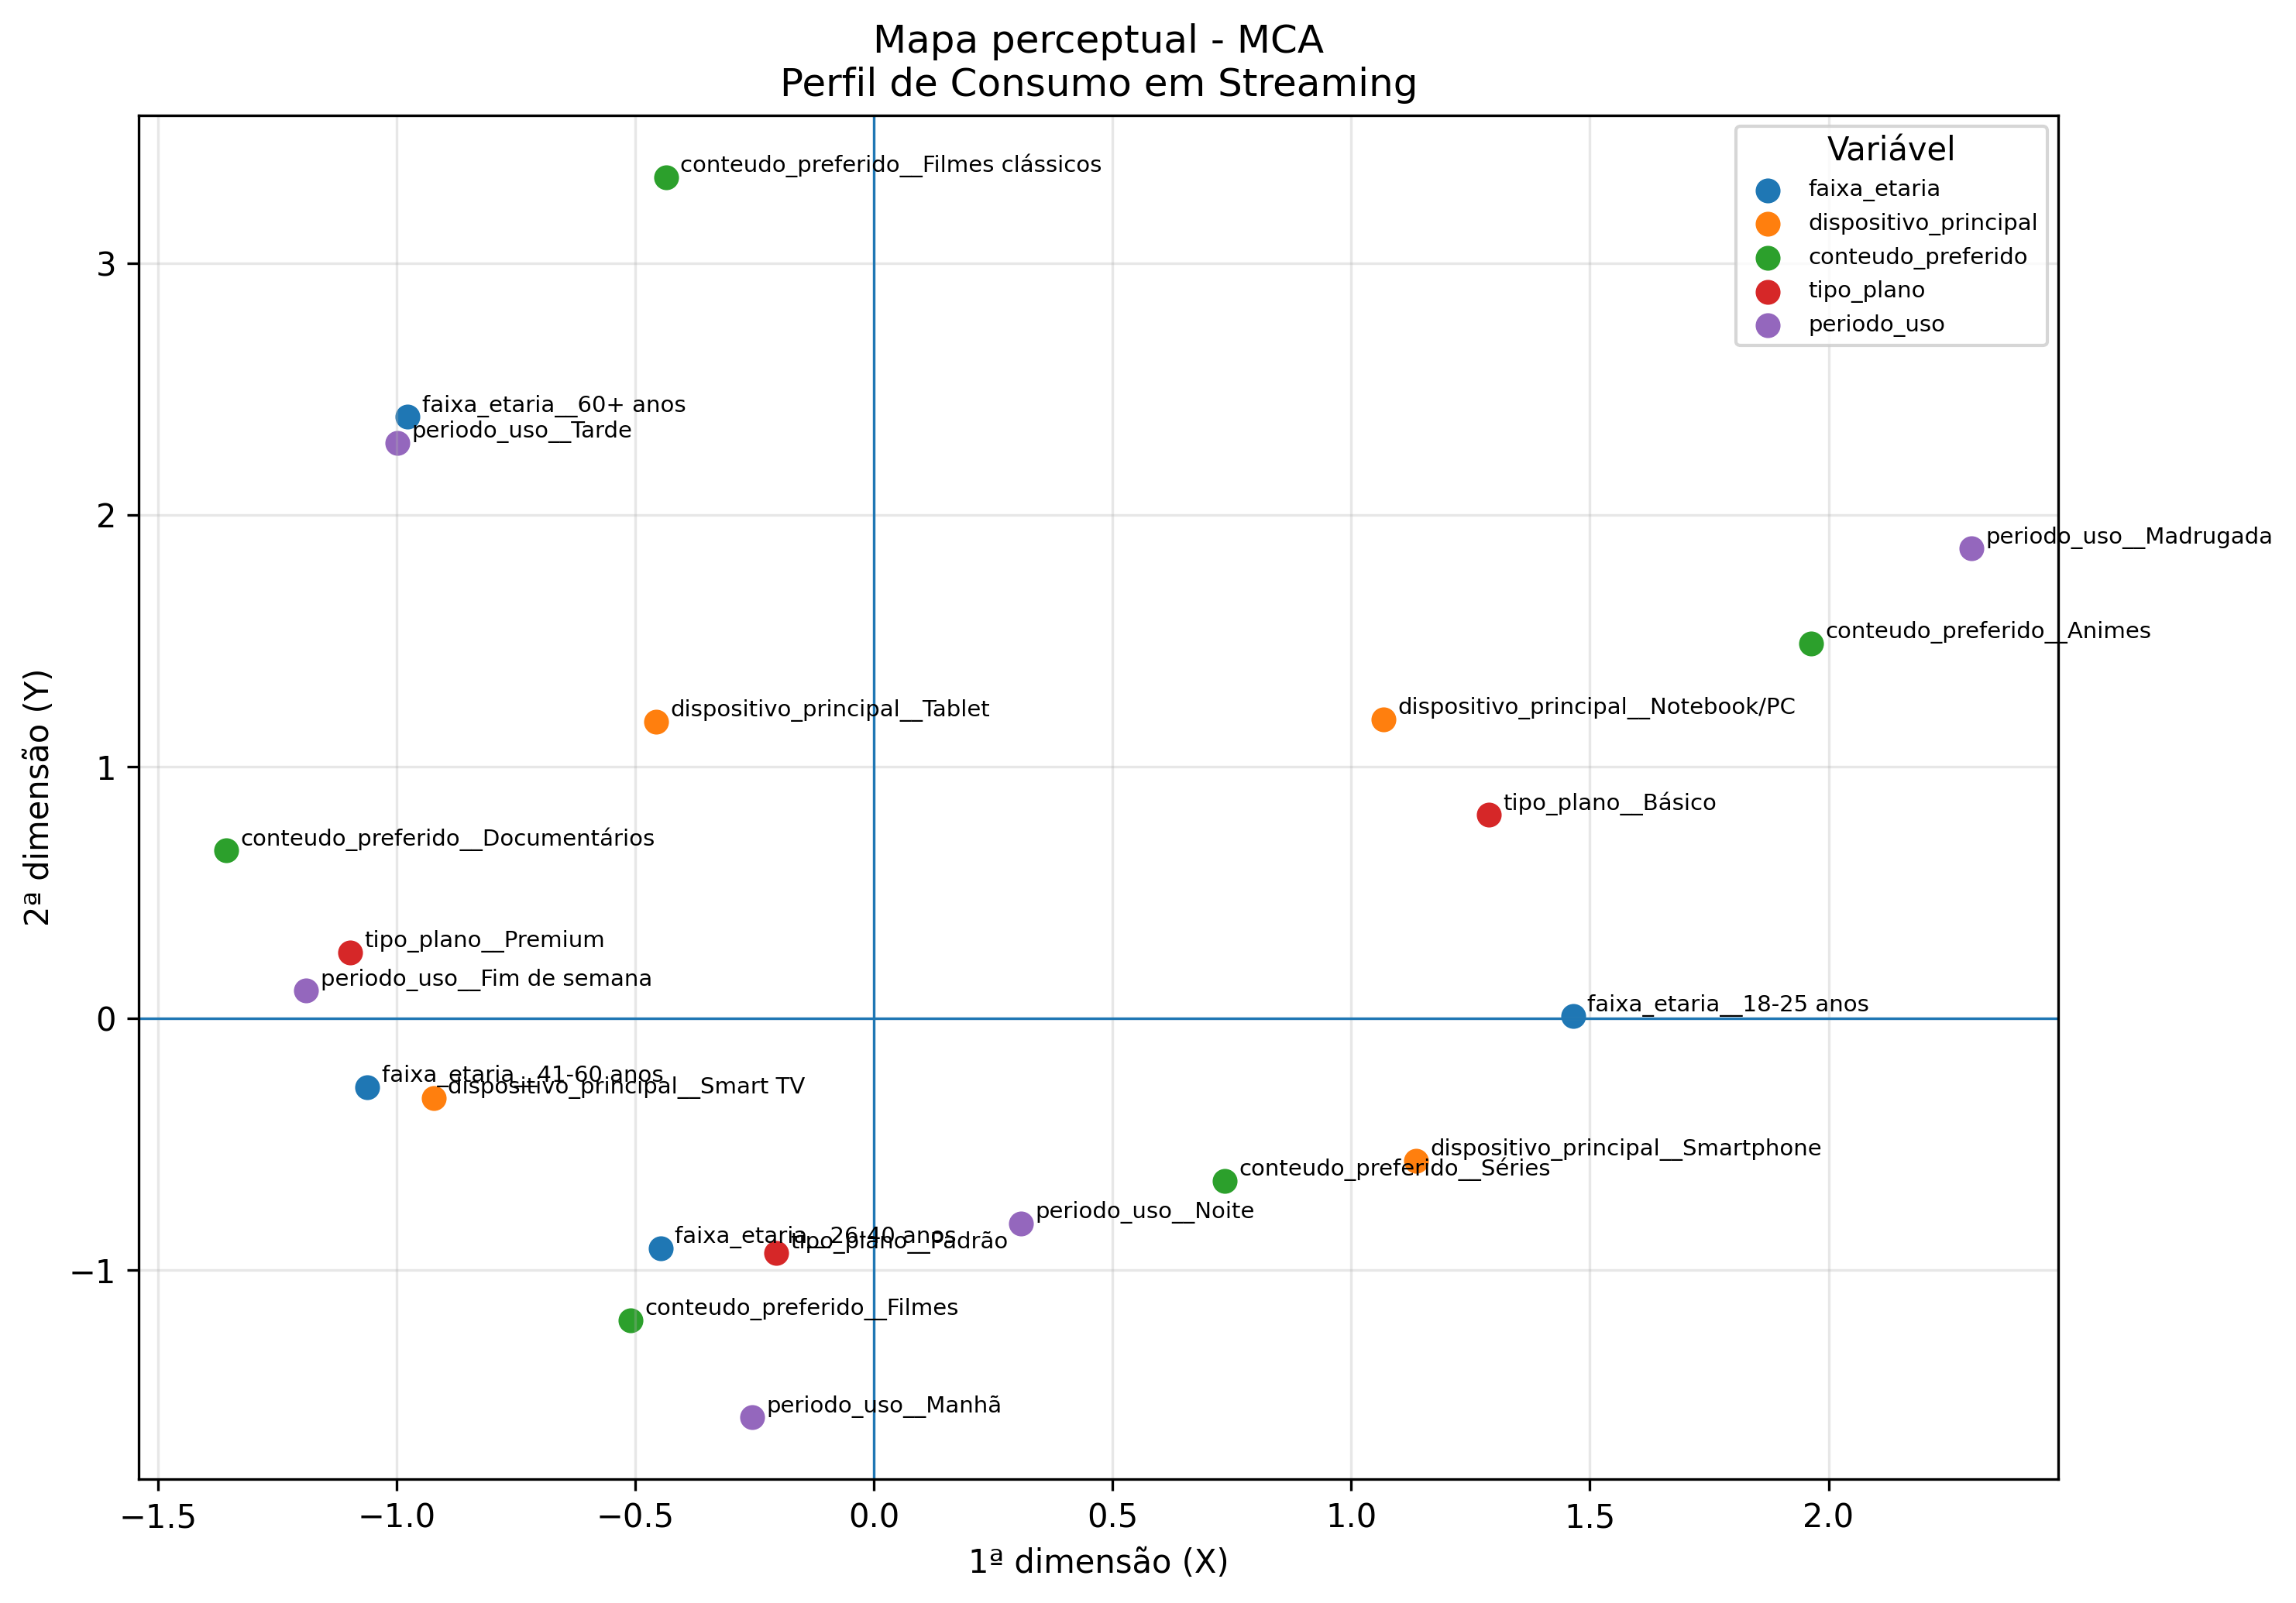

In [16]:
#%% Plotando o mapa perceptual da MCA

# No mapa perceptual, categorias próximas tendem a estar mais associadas.
# O eixo X representa a 1ª dimensão, e o eixo Y representa a 2ª dimensão.

plt.figure(figsize=(10, 7), dpi=300)

variaveis = chart_df_mca["variavel"].unique()

for variavel in variaveis:
    temp = chart_df_mca[chart_df_mca["variavel"] == variavel]
    plt.scatter(temp["x"], temp["y"], label=variavel, s=45)
    
    for _, row in temp.iterrows():
        plt.text(row["x"] + 0.03, row["y"] + 0.02, row["categoria"], fontsize=7)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Mapa perceptual - MCA\nPerfil de Consumo em Streaming")
plt.xlabel("1ª dimensão (X)")
plt.ylabel("2ª dimensão (Y)")
plt.legend(title="Variável", fontsize=7)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretação esperada

O mapa perceptual deve ser interpretado pela proximidade entre as categorias. Categorias próximas no gráfico tendem a apresentar maior associação no banco de dados.

Neste dataset fictício, espera-se observar padrões como:

- clientes mais jovens próximos de **Smartphone**, **Séries**, **Animes** e uso no período da **Noite/Madrugada**;
- clientes adultos próximos de **Smart TV**, **Filmes** e plano **Padrão**;
- clientes mais velhos próximos de **Documentários**, **Filmes clássicos**, **Premium** e uso no período da **Tarde/Fim de semana**.

Essas associações dependem das coordenadas finais calculadas pela MCA.

## Observação

Uma diferença prática importante entre ANACOR e MCA em Python é o formato dos dados de entrada.

Na **ANACOR**, o input costuma ser uma matriz de contingência, construída a partir do cruzamento entre duas variáveis categóricas.

Na **MCA**, o input costuma ser a base original com várias variáveis categóricas, sem necessidade de montar manualmente uma única tabela de contingência.